In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
import pprint
from pathlib import Path
import sys
import os
pd.set_option("display.max_columns", None)

In [30]:
### Changing to parent directory
current_file_path = Path("").resolve()
grandparent_dir = current_file_path.parent.parent
# Append this directory to the system path
sys.path.append(str(grandparent_dir))

In [31]:
filepath = os.path.join(grandparent_dir,"Processed Data/preprocessed_data_final.csv")

### 1. Data

In [32]:
f_val =  96485 / (8.314 * 298)

In [33]:
df = pd.read_csv(filepath)
cols = ["Freq","Modulation (RMS)","File Number","VHr1","VHi1","IHr1","IHi1","IHr2","IHi2"]
orders = ["2nd","4th","6th"]
A_cols = []
for order in orders:
    A_cols.append(f"Re{{A1}}, {order} order")
    A_cols.append(f"Im{{A1}}, {order} order")
    A_cols.append(f"Re{{A2}}, {order} order")
    A_cols.append(f"Im{{A2}}, {order} order")
    
cols = cols + A_cols
df = df[cols]
df = df.reset_index(drop=True)
df

,Freq,Modulation (RMS),File Number,VHr1,VHi1,IHr1,IHi1,IHr2,IHi2,"Re{A1}, 2nd order","Im{A1}, 2nd order","Re{A2}, 2nd order","Im{A2}, 2nd order","Re{A1}, 4th order","Im{A1}, 4th order","Re{A2}, 4th order","Im{A2}, 4th order","Re{A1}, 6th order","Im{A1}, 6th order","Re{A2}, 6th order","Im{A2}, 6th order"
0,0.094659,1mV,1,0.001410,-3.049319e-20,5.078722e-07,4.983661e-07,1.225223e-10,-1.149229e-09,0.000360,0.000353,0.000062,-0.000578,0.000360,0.000353,0.000062,-0.000578,0.000360,0.000353,6.165290e-05,-5.782892e-04
1,0.119335,1mV,1,0.001414,-2.879912e-20,5.706766e-07,5.617096e-07,-1.320847e-10,-9.175286e-10,0.000404,0.000397,-0.000066,-0.000459,0.000404,0.000397,-0.000066,-0.000459,0.000404,0.000397,-6.610590e-05,-4.592059e-04
2,0.150240,1mV,1,0.001414,1.355253e-19,6.397478e-07,6.308609e-07,-2.736589e-10,-4.973401e-10,0.000452,0.000446,-0.000137,-0.000249,0.000452,0.000446,-0.000137,-0.000249,0.000452,0.000446,-1.369701e-04,-2.489256e-04
3,0.189012,1mV,1,0.001414,-3.388132e-20,7.155233e-07,7.081736e-07,8.797291e-11,-7.727625e-10,0.000506,0.000501,0.000044,-0.000386,0.000506,0.000501,0.000044,-0.000387,0.000506,0.000501,4.402941e-05,-3.867586e-04
4,0.238186,1mV,1,0.001415,-1.084202e-19,8.020852e-07,7.966554e-07,1.139039e-10,-4.987984e-10,0.000567,0.000563,0.000057,-0.000249,0.000567,0.000563,0.000057,-0.000249,0.000567,0.000563,5.690452e-05,-2.491914e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.476372,100mV,2,0.141418,-1.517883e-17,4.892856e-05,5.366644e-05,-9.317270e-07,-6.097812e-07,0.000346,0.000379,-0.000047,-0.000030,-0.000386,-0.000424,0.000006,0.000004,0.000089,0.000097,-7.709715e-07,-5.045726e-07
140,0.597895,100mV,2,0.141421,0.000000e+00,5.485060e-05,6.089232e-05,-1.035733e-06,-6.196195e-07,0.000388,0.000431,-0.000052,-0.000031,-0.000433,-0.000481,0.000007,0.000004,0.000100,0.000111,-8.568956e-07,-5.126314e-07
141,0.751563,100mV,2,0.141421,8.673617e-19,6.149965e-05,6.925643e-05,-1.155789e-06,-6.534621e-07,0.000435,0.000490,-0.000058,-0.000033,-0.000486,-0.000547,0.000007,0.000004,0.000112,0.000126,-9.562475e-07,-5.406448e-07
142,0.948695,100mV,2,0.141422,1.387779e-17,6.903134e-05,7.904537e-05,-1.283992e-06,-7.341573e-07,0.000488,0.000559,-0.000064,-0.000037,-0.000545,-0.000624,0.000008,0.000005,0.000125,0.000143,-1.062256e-06,-6.073734e-07


### 2. Fitting Functions

In [34]:
def fit_A1(df,order):
    """
    Returns and prints the A1 model to experimental data for a given Nth-ordered model.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing Re{A1}, Im{A1}, and Frequency columns.
    order : string
        The Nth-order of the desired fit (2nd, 4th, 6th).
    
    Returns
    -------
    kw_fit_dict : dict
        keys are the potential modulations ("1mV", "5mV", etc.) and the values are dictionaries
        containing the "Fit" and "Error" of each Kw parameter for a given order
    """
    
    #A1 Model
    def A1_model(freq, kw):
        f_const = 96485 / 8.314 / 298
        return kw * np.sqrt(freq * 2 * math.pi/2) * f_const * (1 + 1j)
    
    #Extract A1 Data / Frequencies
    kw_fit_dict = {}
    mods = ["1mV","5mV", "10mV", "20mV"] #only fits modulations ≤ 20 mV for first harmonic
    
    for mod in mods:
        df_t = df[df["Modulation (RMS)"].isin([mod])]
        A1_all = df_t[f"Re{{A1}}, {order} order"].to_numpy() + 1j * df_t[f"Im{{A1}}, {order} order"].to_numpy()
        f_all = df_t["Freq"].to_numpy()

        # Stack data: real first, imag second
        A1_all_stacked = np.hstack([A1_all.real, A1_all.imag])
        f_all_stacked = np.hstack([f_all, f_all])

        def A1_stacked_model(f_stacked, kw):
            n = len(f_stacked) // 2 #removes duplication for real/imaginary parts
            freqs = f_stacked[:n]  # all frequencies stacked across voltages
            A_pred = A1_model(freqs, kw)
            return np.hstack([A_pred.real, A_pred.imag])

        p0 = [1e-5]  # initial guess
        popt, pcov = curve_fit(A1_stacked_model, f_all_stacked, A1_all_stacked, p0=p0)
        kw_fit = float(popt[0])
        kw_err = float(np.sqrt(np.diag(pcov))[0])
        kw_fit_dict[mod] = {"Fit": kw_fit,"Error":kw_err}
        
    print(f"Kw Fits for {order} Order:")
    pprint.pprint(kw_fit_dict)

    return kw_fit_dict

In [35]:
kw_fit_2nd = fit_A1(df,"2nd")
kw_fit_4th = fit_A1(df,"4th")
kw_fit_6th = fit_A1(df,"6th")

Kw Fits for 2nd Order:
{'10mV': {'Error': 1.5076092578662875e-08, 'Fit': 1.6430392437998453e-05},
 '1mV': {'Error': 1.552578846268637e-08, 'Fit': 1.6778111351137713e-05},
 '20mV': {'Error': 1.654526910806902e-08, 'Fit': 1.5537443535129662e-05},
 '5mV': {'Error': 1.534792252807051e-08, 'Fit': 1.6703272616191742e-05}}
Kw Fits for 4th Order:
{'10mV': {'Error': 1.5367372403125675e-08, 'Fit': 1.6747904971371296e-05},
 '1mV': {'Error': 1.5528702503406405e-08, 'Fit': 1.678129299789916e-05},
 '20mV': {'Error': 1.790413077170266e-08, 'Fit': 1.6812408428989547e-05},
 '5mV': {'Error': 1.542113052760848e-08, 'Fit': 1.6782810376575624e-05}}
Kw Fits for 6th Order:
{'10mV': {'Error': 1.535987218998554e-08, 'Fit': 1.6739727849414664e-05},
 '1mV': {'Error': 1.5528701658458965e-08, 'Fit': 1.6781292193500993e-05},
 '20mV': {'Error': 1.7756546116043956e-08, 'Fit': 1.6674062261791686e-05},
 '5mV': {'Error': 1.5420664904526855e-08, 'Fit': 1.6782305400425702e-05}}


In [36]:
def fit_A2(df,order, kw_dict):
    """
    Returns and prints the A2 model to experimental data for a given
    Nth-ordered model and fixed kw.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing Re{A2*}, Im{A2*}, and Frequency columns.
    order : string
        The Nth-order of the desired fit (2nd, 4th, 6th).
    kw_known : float
        The known value of kw (not fitted).
    
    Returns
    -------
    delta_fit_dict : dict
        keys are the potential modulations ("1mV", "5mV", etc.) and the values are dictionaries
        containing the "Fit" and "Error" of each delta parameter for a given order and Kw value
    """
    
    #Extract A2 Data / Frequencies
    delta_fit_dict = {}
    mods = ["5mV", "10mV", "20mV"] #only fits modulations ≤ 20 mV and > 1 mV for second harmonic
    for mod in mods:
        df_t = df[df["Modulation (RMS)"].isin([mod])]
        A2_all = df_t[f"Re{{A2}}, {order} order"].to_numpy() + 1j * df_t[f"Im{{A2}}, {order} order"].to_numpy()
        f_all = df_t["Freq"].to_numpy()
        kw_known = kw_dict[mod]["Fit"]
        kw_err = kw_dict[mod]["Error"]
        
        # A2 model with fixed kw
        def A2_model(freq, d):
            f = 96485 / 8.314 / 298
            return -d * kw_known / 8 * np.sqrt(2 * freq * 2 * math.pi / 2) * f**2 * (1 + 1j)

        # Stack data: real first, imag second
        A2_all_stacked = np.hstack([A2_all.real, A2_all.imag])
        f_all_stacked = np.hstack([f_all, f_all])

        def A2_stacked_model(f_stacked, d):
            n = len(f_stacked) // 2
            freqs = f_stacked[:n]
            A_pred = A2_model(freqs, d)
            return np.hstack([A_pred.real, A_pred.imag])
        
        p0 = [1.0]  # initial guess for d
        popt, pcov = curve_fit(A2_stacked_model, f_all_stacked, A2_all_stacked, p0=p0)
        
        # Errors
        d_fit = float(popt[0])
        d_err = float(np.sqrt(np.diag(pcov))[0])
        delta_fit_dict[mod] = {"Fit": d_fit,"Error":d_err}

    print(f"Delta Fits for {order} Order:")
    pprint.pprint(delta_fit_dict)
    
    return delta_fit_dict

In [37]:
d_fit_2nd = fit_A2(df,"2nd",kw_fit_2nd)
d_fit_4th = fit_A2(df,"4th",kw_fit_4th)
d_fit_6th = fit_A2(df,"6th",kw_fit_6th)

Delta Fits for 2nd Order:
{'10mV': {'Error': 0.0005447469481581258, 'Fit': 0.08336068892619768},
 '20mV': {'Error': 0.0008569745172490762, 'Fit': 0.07375713774394298},
 '5mV': {'Error': 0.0009347965141414275, 'Fit': 0.0911252121604071}}
Delta Fits for 4th Order:
{'10mV': {'Error': 0.0005862944995738506, 'Fit': 0.08971785255256909},
 '20mV': {'Error': 0.0012259805421763802, 'Fit': 0.10549974198753741},
 '5mV': {'Error': 0.0009514104448384952, 'Fit': 0.0927445275427508}}
Delta Fits for 6th Order:
{'10mV': {'Error': 0.0005822182902838943, 'Fit': 0.08909420467650868},
 '20mV': {'Error': 0.001057225678389603, 'Fit': 0.09098747182139717},
 '5mV': {'Error': 0.0009510239530444516, 'Fit': 0.09270686103772292}}


### 3. Plotting Functions

In [38]:
fontsize=12
label_fontsize = 12
legend_fontsize = 5
axis_fontsize = 6.8

In [39]:
def add_fraction_diagonal_arrow(ax,
                                start_frac,
                                end_frac,
                                offset_frac=-0.1,
                                label=r'$\omega$',
                                fontsize=14,
                                lw=1.8):
    """
    Draw a diagonal arrow whose start/end are fractions of axis limits,
    with a vertical offset that is always visually downward for negative offsets.
    """

    # --- Axis limits ---
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # --- Fraction → data (works for negative, reversed, log, etc.) ---
    x0 = xmin + start_frac * (xmax - xmin)
    x1 = xmin + end_frac   * (xmax - xmin)

    y0 = ymin + start_frac * (ymax - ymin)
    y1 = ymin + end_frac   * (ymax - ymin)

    # --- Convert data → display ---
    start_disp = ax.transData.transform((x0, y0))
    end_disp   = ax.transData.transform((x1, y1))

    # --- Apply vertical offset in DISPLAY space (always down) ---
    offset_pixels = offset_frac * ax.bbox.height
    start_disp = (start_disp[0], start_disp[1] + offset_pixels)
    end_disp   = (end_disp[0],   end_disp[1]   + offset_pixels)

    # --- Back to data space ---
    x0o, y0o = ax.transData.inverted().transform(start_disp)
    x1o, y1o = ax.transData.inverted().transform(end_disp)

    # --- Draw arrow ---
    ax.annotate(
        "",
        xy=(x1o, y1o),
        xytext=(x0o, y0o),
        arrowprops=dict(arrowstyle="->", lw=lw, color="black")
    )

    # --- Label ---
    # Determine arrow direction in DISPLAY space
    p0 = ax.transData.transform((x0o, y0o))
    p1 = ax.transData.transform((x1o, y1o))

    # If arrow points right on screen, tail is start; otherwise swap
    if p1[0] < p0[0]:
        xt, yt = x0o, y0o  # tail
        xh, yh = x1o, y1o  # head
    else:
        xt, yt = x1o, y1o
        xh, yh = x0o, y0o

    # Fraction measured from the tail
    t = 0.35
    xm = xt + t * (xh - xt)
    ym = yt + t * (yh - yt)

    # --- Label (offset in DISPLAY space, always downward) ---
    text_disp = ax.transData.transform((xm, ym))

    text_offset_pixels = 0.035 * ax.bbox.height
    text_disp = (text_disp[0], text_disp[1] - text_offset_pixels)

    xt, yt = ax.transData.inverted().transform(text_disp)

    ax.text(
        xt,
        yt,
        label,
        ha="center",
        va="top",
        fontsize=fontsize
    )

In [40]:
def plot_corrected_admittance(ax,order,labels,markers,colors,sizes,df,harmonic_j,x_min,x_max,y_min,y_max,arrow_start, arrow_end,offset,subplot_label,unit):
    
    # Normalize colors from 0-255 to 0-1
    colors = [tuple(c/255 for c in color) for color in colors]

    # Plotting Parameters for Each Harmoinic (1 or 2)
    linewidth = .4
    if harmonic_j == 1:
        mods = ["1mV","5mV","10mV","20mV"]
        name1 = f"Re{{A1}}, {order} order"
        name2 = f"Im{{A1}}, {order} order"
        labels = labels[0:len(mods)]
        markers = markers[0:len(mods)]
        colors = colors[0:len(mods)]
        sizes = sizes[0:len(mods)]
    elif harmonic_j == 2:
        mods = ["5mV","10mV","20mV"]
        name1 = f"Re{{A2}}, {order} order"
        name2 = f"Im{{A2}}, {order} order"
        labels = labels[1:len(mods)+1]
        markers = markers[1:len(mods)+1]
        colors = colors[1:len(mods)+1]
        sizes = sizes[1:len(mods)+1]

    for i in range(0,len(sizes)):
        #Plotting Parameters
        label_val = labels[i]
        shape = markers[i]
        color_val = colors[i]
        size = sizes[i]
        mod = mods[i]
        df_t = df[df["Modulation (RMS)"] == mod]

        #Admittance
        real_A = df_t[name1]
        imag_A = df_t[name2]
        if harmonic_j == 2:
            real_A = -real_A
            imag_A = -imag_A

        # Plot Unfilled Markers in Scatter Plot
        if (shape == "+"):
            ax.scatter(real_A, imag_A, color=color_val, label=label_val,
                    zorder=5, s=size, linewidth=linewidth, marker=shape)
        else:
            ax.scatter(real_A, imag_A, facecolors='none', label=label_val,
                s=size, linewidth=linewidth, marker=shape, edgecolor=color_val,zorder=5)

    # 45-degree gray line spanning data range
    ax.plot([x_min, x_max], [y_min,y_max], color='gray', linestyle='-', linewidth=0.3, alpha=0.5, zorder=1)

    # Format Axes
    sign = ""
    if harmonic_j == 2:
        sign = r"$-$"
    ax.set_xlabel(rf'{sign}Re{{$\tilde{{A}}_{{{harmonic_j},\!\mathrm{{proc}}}}$}}, ${unit}$',fontsize=fontsize)
    ax.set_ylabel(rf'{sign}Im{{$\tilde{{A}}_{{{harmonic_j},\!\mathrm{{proc}}}}$}}, ${unit}$',fontsize=fontsize)
    ax.set_aspect('equal', adjustable='box')

    # Format Grid/Tick marks
    ax.grid(True, which='major', linestyle='-', linewidth=0.3, color='gray', alpha=0.5)
    ax.set_xlim(x_min,x_max)
    ax.set_ylim(y_min,y_max)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.0004))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.0004))
    ax.minorticks_on()
    ax.tick_params(which='minor', labelbottom=False, labelleft=False, direction='in',
                   length=3, width=0.6, color='black')
    ax.tick_params(which='major', direction='in', labelsize=axis_fontsize,length=5,width=0.75)

    # #Remove decimals from 0 at origin
    def custom_formatter(x, pos): 
        return '0' if abs(x) < 1e-9 else f'{x:.4f}'
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))

    # Legend
    ax.text(0.03, 0.97, subplot_label, transform=ax.transAxes,
        fontsize=label_fontsize, fontweight='bold', va='top', ha='left')
    
    add_fraction_diagonal_arrow(ax,
                                arrow_start,
                                arrow_end,
                                offset_frac=offset,
                                label=r'$\omega$',
                                fontsize=8,
                                lw=1)

    #Tight layout
    plt.tight_layout()

In [ ]:
def plot_parameter_spectrum(ax,fit_parameter_dict,harmonic_j,error_mult,x_min,x_max,y_min,y_max,subplot_label):
    
    # Axis Parameters for Each Harmoinic (1 or 2)
    if harmonic_j == 1:
        y_axis_label = rf'$K_W$ $(A•s^{{-1/2}})$'
        val_mult = 10**5
        ax.text(
            0.0025, 1.005,          # x, y in axes coordinates (0-1)
            rf'$\times 10^{{{5}}}$', 
            transform=ax.transAxes,
            fontsize=8,
            fontweight='bold',
            va='bottom', ha='left'
        )
        x_axis_tick = 5
        y_axis_tick = 0.1

    elif harmonic_j == 2:
        y_axis_label = rf'$\delta$'
        val_mult = 1
        x_axis_tick = 5
        y_axis_tick = 0.02

    # Plot Parameter Scatter Plot (and error bars for first harmonic)
    linewidth = .4
    y_fits = []
    x_mods = []
    for mod in fit_parameter_dict:
        y_fit = fit_parameter_dict[mod]["Fit"]*val_mult
        x_mod = int(mod[:-2]) * np.sqrt(2) #convert RMS Voltage Label to Peak Voltage, V_p
        ax.scatter(x_mod, y_fit, s=10, marker="o", color="black", linewidth=linewidth,zorder=5)
        y_fits.append(y_fit); x_mods.append(x_mod)
        error_val = fit_parameter_dict[mod]["Error"]*error_mult*val_mult
        ax.errorbar(x_mod, y_fit, yerr=error_val, fmt='none', capsize=2, elinewidth=0.5, color='black',capthick=0.5)
    
    #Plot Std Deviation Line / Shaded Region
    y_mean = np.mean(y_fits)
    y_std  = np.std(y_fits, ddof=1)
    ax.axhline(y_mean, color='black', linestyle="solid", linewidth=0.3)
    ax.axhspan(y_mean - y_std, y_mean + y_std, facecolor='grey', edgecolor='none', alpha=0.2)
    y_mean /= val_mult; y_std/= val_mult

    #Set Axis Labels
    ax.set_xlabel("$∆E$, $mV$", fontsize=fontsize)
    ax.set_ylabel(y_axis_label, fontsize=fontsize)
    
    # Fromat Grid/Tick Marks
    ax.grid(True, which='major', linestyle='-', linewidth=0.3, color='gray', alpha=0.5)
    ax.set_xlim(x_min,x_max)
    ax.set_ylim(y_min,y_max)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(x_axis_tick))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(y_axis_tick))
    ax.minorticks_on()
    ax.tick_params(which='minor', labelbottom=False, labelleft=False, direction='in',
                   length=3, width=0.6, color='black')
    ax.tick_params(which='major', direction='in', labelsize=axis_fontsize,length=5,width=0.75)

    # Remove Decimals from 0 at Origin
    def custom_formatter(x, pos):
        return '0' if abs(x) < 1e-9 else f'{x:.0f}'
    def custom_formatter2(x, pos):
        return '0' if abs(x) < 1e-9 else f'{x:.2f}'
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(custom_formatter2))

    # Plot Label
    ax.text(0.03, 0.97, subplot_label, transform=ax.transAxes,
        fontsize=label_fontsize, fontweight='bold', va='top', ha='left')

    #Tight Layout
    plt.tight_layout()
    
    return y_mean, y_std

### Shared Plotting Variables

In [42]:
subplot_labels = ['(a)', '(c)', '(e)', '(b)', '(d)', '(f)']
fact = 0.22
labels = [1, 5, 10, 20, 50, 100]
labels = [f"{round(x*np.sqrt(2),3)} mV" for x in labels]
markers = ["o", "s", "^", "+", "D", "*"]
colors = [(234, 51, 35), (240, 152, 55), (0, 0, 0), (103, 23, 145), (79, 173, 243), (106, 229, 108)]
sizes = [35*fact,30*fact,35*fact,45*fact,25*fact,80*fact]
kw_fit_dicts = [kw_fit_2nd,kw_fit_4th,kw_fit_6th]
d_fit_dicts = [d_fit_2nd,d_fit_4th,d_fit_6th]
orders = ["2nd","4th","6th"]

### 4. Plots

### A1

Run 1


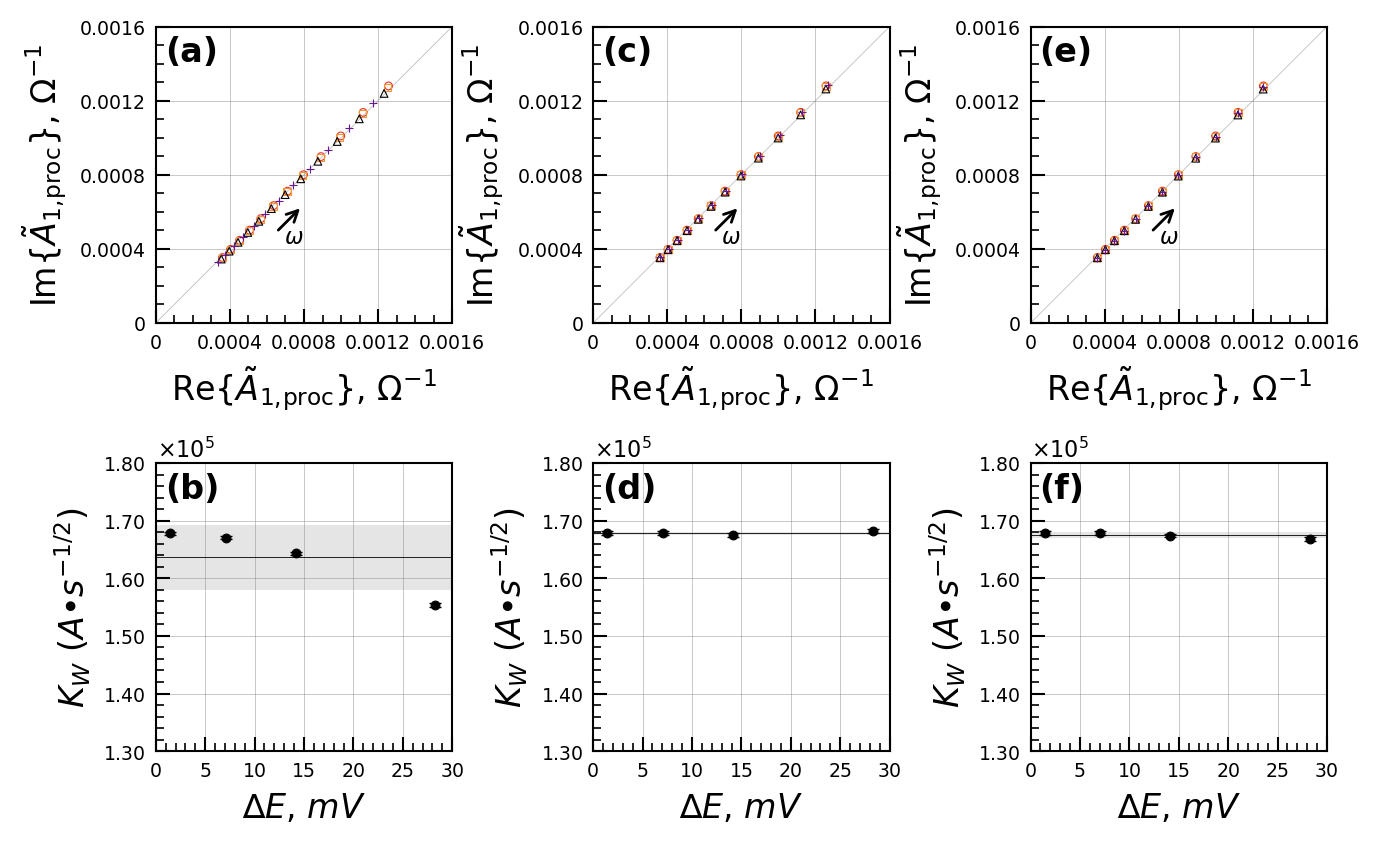

Run 2


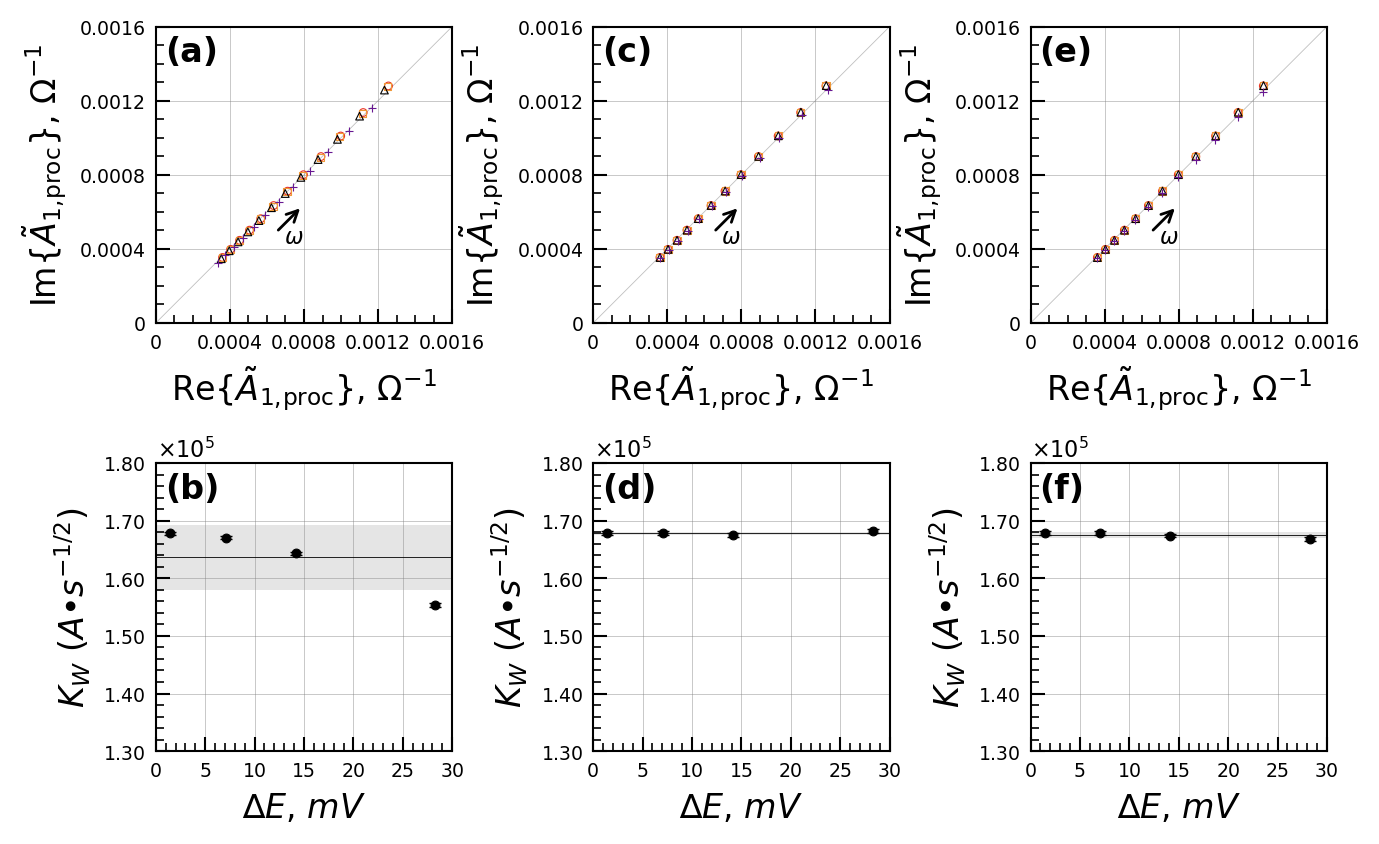

In [ ]:
#For Run 1 and Run 2
for run_num in range(1,3):
    
    #Create Figure
    fig, axs = plt.subplots(
        nrows=2, ncols=3, figsize=(7, 6.5),
        gridspec_kw={'height_ratios': [4.1,1]},
        dpi=200
    )
    for ax in axs.flat:
        for location in ['left', 'right', 'top', 'bottom']:
            ax.spines[location].set_linewidth(0.75)
    
    #Generate Run File Data
    df_t = df[df["File Number"] == run_num]

    #A1 Admittance Subplots (a), (c), (e)
    for i,idx in enumerate(range(3)):
        ax = axs[0][idx]
        harmonic_j = 1
        x_min = 0
        x_max = 0.0016
        y_min = 0
        y_max = 0.0016
        arrow_start = 0.4
        arrow_end = 0.5
        offset = -0.1  # small offset below the 45-line
        subplot_label = subplot_labels[i]

        # Plot Admittance
        plot_corrected_admittance(ax, orders[i],labels, markers, colors, sizes,
                                df_t, harmonic_j,
                                x_min, x_max, y_min, y_max,
                                arrow_start, arrow_end, offset,subplot_label,r"{\Omega}^{-1}")
    #Kw Fit Subplots (b), (d), (f)
    Kw_means, Kw_stdevs = {}, {}
    for i,idx in enumerate(range(3)):
        ax = axs[1][idx]
        subplot_label = subplot_labels[i+3]
        y_mean, y_stdev = plot_parameter_spectrum(ax,kw_fit_dicts[i],harmonic_j=1,error_mult=1.96,x_min = 0,x_max = 30,y_min=1.3,y_max=1.8,subplot_label=subplot_label)
        Kw_means[orders[i]]= y_mean; Kw_stdevs[orders[i]] = y_stdev
        
    #Show/Save Figures    
    plt.tight_layout(h_pad=1.8,w_pad=-1)
    if run_num == 1:
        plt.savefig(f"Figure5_A1_Plot_Run{run_num}.pdf",bbox_inches='tight', pad_inches=0.01)
    else:
        plt.savefig(f"S8_A1_Plot_Run{run_num}.pdf",bbox_inches='tight', pad_inches=0.01)
    print(f"Run {run_num}")
    plt.show()



### A2

Run 1


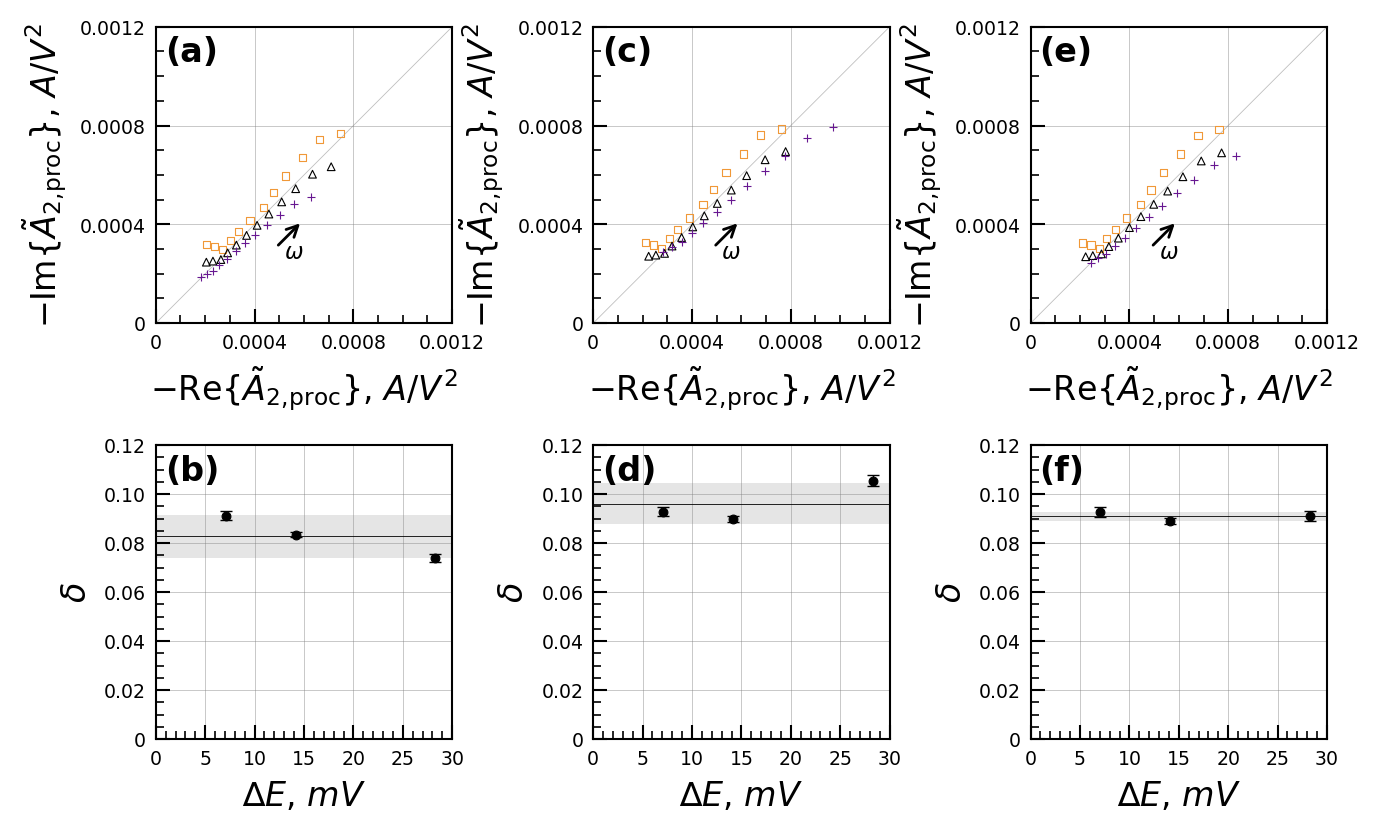

Run 2


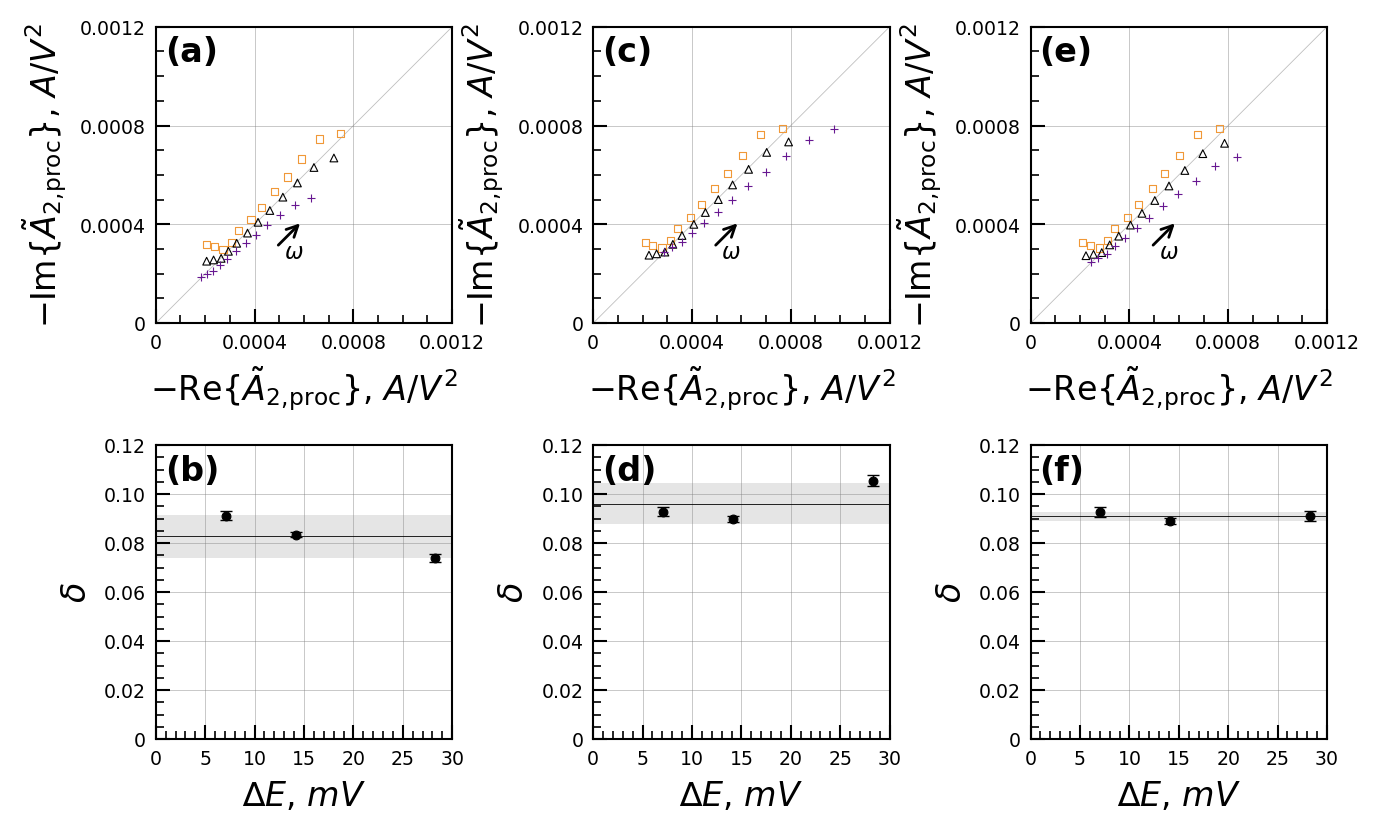

In [44]:
#For Run 1 and Run 2
for run_num in range(1,3):
    
    #Create Figure
    fig, axs = plt.subplots(
        nrows=2, ncols=3, figsize=(7, 6.5),
        gridspec_kw={'height_ratios': [4.1,1]},
        dpi = 200
    )
    for ax in axs.flat:
        for location in ['left', 'right', 'top', 'bottom']:
            ax.spines[location].set_linewidth(0.75)
        
    #Generate Run File Data
    df_t = df[df["File Number"] == run_num]

    #A2 Admittance Subplots (a), (c), (e)
    for i,idx in enumerate(range(3)):
        ax = axs[0][idx]
        harmonic_j = 2
        x_min = 0
        x_max = 0.0012
        y_min = 0
        y_max = 0.0012
        arrow_start = 0.4
        arrow_end = 0.5
        offset = -0.15  # small offset below the 45-line
        subplot_label = subplot_labels[i]

        #Plot Admittance
        plot_corrected_admittance(ax, orders[i],labels, markers, colors, sizes,
                                df_t, harmonic_j,
                                x_min, x_max, y_min, y_max,
                                arrow_start, arrow_end, offset,subplot_label,r"{A/V^{2}}")
    #Delta Fit Subplots (b), (d), (f)
    delta_means, delta_stdevs = {}, {}
    for i,idx in enumerate(range(3)):  # You have 6 subplots
        ax = axs[1][idx]
        subplot_label = subplot_labels[i+3]
        y_mean, y_stdev = plot_parameter_spectrum(ax,d_fit_dicts[i],harmonic_j=2,error_mult=1.96,x_min =0,x_max = 30,y_min=0,y_max=0.12,subplot_label=subplot_label)
        delta_means[orders[i]]= y_mean; delta_stdevs[orders[i]] = y_stdev
    
    #Show/Save Figures    
    plt.tight_layout(h_pad=1.8,w_pad=-1)
    if run_num == 1:
        plt.savefig(f"Figure6_A2_Plot_Run{run_num}.pdf",bbox_inches='tight', pad_inches=0.01)
    else:
        plt.savefig(f"S9_A2_Plot_Run{run_num}.pdf",bbox_inches='tight', pad_inches=0.01)
    print(f"Run {run_num}")
    plt.show()


### 5. Calculating Diffusion Coefficients

In [45]:
F = 96485 #C/mol
A = ((3*10**(-3))/2)**2*math.pi #m^2
C = (50*10**(-3)*800*10**(-6)) / ((20*10**(-3)+800*10**(-6)) * 0.001) #mol/m3
R = 8.314 #J/mol-K
T = 298 #K
kw_fits = {"2nd":kw_fit_2nd,"4th":kw_fit_4th,"6th":kw_fit_6th}
d_fits = {"2nd":d_fit_2nd,"4th":d_fit_4th,"6th":d_fit_6th}
D_vals = {}
for order in kw_fits:
    kw_dict = kw_fits[order]
    delta_dict = d_fits[order]
    temp_dict = {}
    for mod in kw_dict:
        if mod == "1mV":
            continue
        else:
            kw = kw_dict[mod]["Fit"]
            kw_std = Kw_stdevs[order] #using standard deviations as error
            delta = delta_dict[mod]["Fit"]
            delta_std = delta_stdevs[order] #using standard deviations as error
            
            #Error propogation when constants assumed to have no error
            D0 = (kw * 2 / (F*A*C))**2 * 10000 #cm2/s
            D0_err = 2 * D0 * kw_std / kw

            #Error Propogation of General Function: σ_f² = Σ (∂f/∂xᵢ * σ_xᵢ)²
            DII = D0 * (1-delta) #cm2/s
            DII_err = math.sqrt( (D0_err * (1 - delta))**2 + (D0 * delta_std)**2 )
            DIII = D0 * (1+delta) #cm2/s
            DIII_err = math.sqrt( (D0_err * (1 + delta))**2 + (D0 * delta_std)**2 )
            
            temp_dict[mod] = {"D0":{"Fit":D0,"Error":D0_err},
                            "DII":{"Fit":DII,"Error":DII_err},
                            "DIII":{"Fit":DIII,"Error":DIII_err}}
    D_vals[order] = temp_dict

In [46]:
DII_err

3.7721314050072755e-08

In [47]:
def round_to_error(val, err):
    if err == 0:
        return val, 0
    order = int(np.floor(np.log10(abs(err))))
    rounded_err = round(err, -order)
    rounded_val = round(val, -order)
    return rounded_val, rounded_err

#10 mV Diffusion Values
D_2nd = D_vals["2nd"]["10mV"]
D_4th = D_vals["4th"]["10mV"]
D_6th = D_vals["6th"]["10mV"]
D_dicts = [D_2nd, D_4th, D_6th]
models = ["2nd Order", "4th Order", "6th Order"]

#Calculating the Errors
rows = []
orders = ["2nd","4th","6th"]
for model, d, order in zip(models, D_dicts, orders):
    # Convert to 10^6 cm^2/s
    D0_val = d['D0']['Fit'] * 1e6
    D0_err = d['D0']['Error'] * 1e6
    DII_val = d['DII']['Fit'] * 1e6
    DII_err = d['DII']['Error'] * 1e6
    DIII_val = d['DIII']['Fit'] * 1e6
    DIII_err = d['DIII']['Error'] * 1e6
    
    # Round to first significant digit of error
    D0_val_r, D0_err_r = round_to_error(D0_val, D0_err)
    DII_val_r, DII_err_r = round_to_error(DII_val, DII_err)
    DIII_val_r, DIII_err_r = round_to_error(DIII_val, DIII_err)
    
    # Format as "value ± error"
    D0_str = f"{D0_val_r} ± {D0_err_r}"
    DII_str = f"{DII_val_r} ± {DII_err_r}"
    DIII_str = f"{DIII_val_r} ± {DIII_err_r}"
    kw_str = round(kw_fits[order]["10mV"]["Fit"] * 10**5,3)
    delta_str = round(d_fits[order]["10mV"]["Fit"],3)
    
    rows.append([model, D0_str, DII_str, DIII_str,kw_str,delta_str])

# Create DataFrame
df_table = pd.DataFrame(rows, columns=[
    "Model", r"D^0 (10^-6 cm^2/s)",
    r"D^II (10^-6 cm^2/s))",
    r"D^III (10^-6 cm^2/s))",
    r"K_W (10^5 A*s^0.5)",
    "delta"
])
df_table

,Model,D^0 (10^-6 cm^2/s),D^II (10^-6 cm^2/s)),D^III (10^-6 cm^2/s)),K_W (10^5 A*s^0.5),delta
0,2nd Order,6.3 ± 0.4,5.8 ± 0.4,6.8 ± 0.5,1.643,0.083
1,4th Order,6.52 ± 0.02,5.94 ± 0.06,7.11 ± 0.06,1.675,0.090
2,6th Order,6.52 ± 0.04,5.94 ± 0.04,7.1 ± 0.04,1.674,0.089


In [48]:
DII_lit = (5.88+6.71)/2
DIII_lit = (6.77+7.74)/2
delta_lit = (0.0368+0.0787)/2
delta_check = d_fits["6th"]["10mV"]["Fit"]
percent_diff_DII = abs(D_dicts[2]["DII"]["Fit"]*10**6 - DII_lit) / DII_lit * 100
percent_diff_DIII = abs(D_dicts[2]["DIII"]["Fit"]*10**6 - DIII_lit) / DIII_lit * 100
percent_diff_delta = abs(delta_check - delta_lit) / delta_lit * 100
print(f"D_II Lit % Difference: {round(percent_diff_DII,2)}%")
print(f"D_III Lit % Difference: {round(percent_diff_DIII,2)}%")
print(f"Delta Lit % Difference: {round(percent_diff_delta,2)}%")

D_II Lit % Difference: 5.71%
D_III Lit % Difference: 2.18%
Delta Lit % Difference: 54.28%


In [49]:
kw_1mV_diff = abs(1 - kw_fits["2nd"]["20mV"]["Fit"] / kw_fits["2nd"]["1mV"]["Fit"]) * 100
d_5mV_diff_2nd = abs(1 - d_fits["2nd"]["20mV"]["Fit"] / d_fits["2nd"]["5mV"]["Fit"]) * 100
d_5mV_diff_4th = abs(1 - d_fits["4th"]["20mV"]["Fit"] / d_fits["4th"]["5mV"]["Fit"]) * 100
d_5mV_diff_6th = abs(1 - d_fits["6th"]["20mV"]["Fit"] / d_fits["6th"]["5mV"]["Fit"]) * 100
print(f"Kw at 20 mV Within % of 1 mV: {round(kw_1mV_diff,2)}%")
print(f"Delta at 20 mV Within % of 5 mV (2nd Order): {round(d_5mV_diff_2nd,2)}%")
print(f"Delta at 20 mV Within % of 5 mV (4th Order): {round(d_5mV_diff_4th,2)}%")
print(f"Delta at 20 mV Within % of 5 mV (6th Order): {round(d_5mV_diff_6th,2)}%")

Kw at 20 mV Within % of 1 mV: 7.39%
Delta at 20 mV Within % of 5 mV (2nd Order): 19.06%
Delta at 20 mV Within % of 5 mV (4th Order): 13.75%
Delta at 20 mV Within % of 5 mV (6th Order): 1.85%
